In [48]:
import pandas as pd
from sklearn.svm import SVC as SVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
from sklearn.feature_extraction.text import TfidfVectorizer 
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# collection data
df = pd.read_csv("dataset_for_SVM.csv")
# df
checking_null_values = df.isnull().sum()
checking_duplicate_values = df.duplicated().sum()
checking_duplicate_values

np.int64(0)

C:\Users\E-TIME\AppData\Local\Temp\ipykernel_7896\4277477366.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


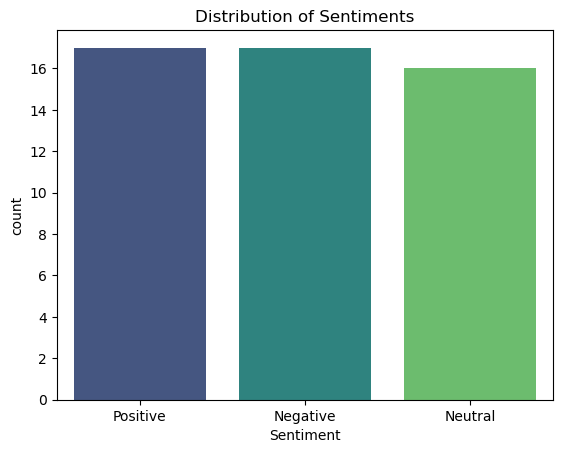

In [50]:
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments')
plt.show()

In [51]:
# CLEANING: Remove any empty rows (Missing Values)
# This prevents "Input contains NaN" errors
# df = df.dropna(subset=['Review', 'Sentiment'])

In [52]:
# Assign features
X = df["Review"]
y = df["Sentiment"]

In [53]:
# Convert Text to Numbers (Only for X!)
vectorizer = TfidfVectorizer()
X_numeric = vectorizer.fit_transform(X)


In [54]:
# Splitting of dataset into training and testing (randomly)
X_train, X_test, y_train, y_test = train_test_split(X_numeric,y,test_size=0.2)

In [55]:
# Train the Model
model = SVM(kernel="linear")
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [56]:
predicted_y = model.predict(X_test)
predicted_y

array(['Neutral', 'Positive', 'Neutral', 'Positive', 'Neutral', 'Neutral',
       'Neutral', 'Positive', 'Neutral', 'Neutral'], dtype=object)

In [57]:
result = accuracy_score(predicted_y, y_test)
result

0.7

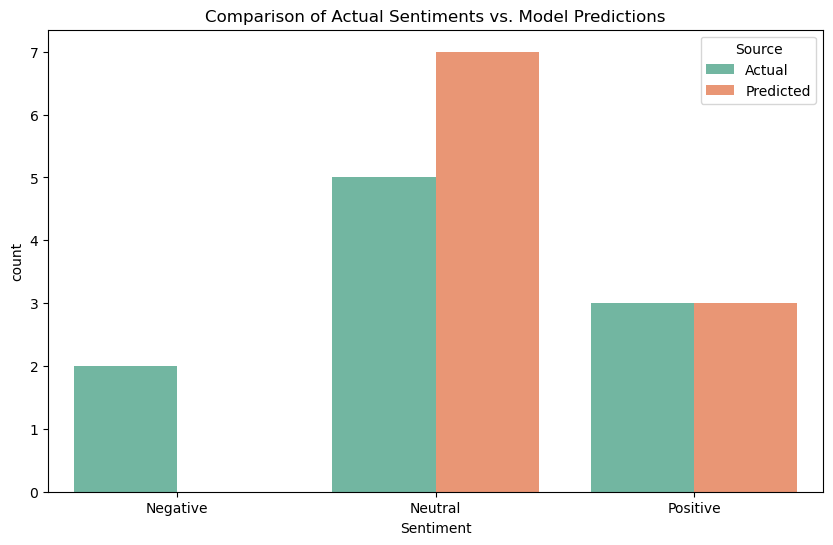

In [58]:
# Create a comparison dataframe
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predicted_y})
melted_df = comparison_df.melt(var_name='Source', value_name='Sentiment')

# Plot comparison
plt.figure(figsize=(10, 6))
sns.countplot(data=melted_df, x='Sentiment', hue='Source', palette='Set2')
plt.title('Comparison of Actual Sentiments vs. Model Predictions')
plt.show()